In [12]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

# Need the external data modules on path
import os, sys
external_path = os.getcwd()
sys.path.append(external_path)

# Now my standard imports
import numpy as np
from matplotlib import pyplot as plt
from vrAnalysis.helpers import Timer, format_spines, beeswarm, errorPlot, save_figure
from dimilibi import PCA, make_time_splits

# Special module imports for external data
from stringer2019 import StringerRegistry

plt.rcParams["font.size"] = 14

In [36]:
reg = StringerRegistry()
print(reg)
reg.available()

reg.list(stimset="natimg32")

StringerRegistry(32 sessions, 7 mice, 7 stimulus types)
mouse_name      date          stimset                 mouse_type          nplanes 
--------------  ------------  ----------------------  ------------------  --------
M160825_MP027   2016-12-14    natimg2800              EMX_G6s             12      
M161025_MP030   2017-05-29    natimg2800              TETO_G6s            12      
M170604_MP031   2017-06-28    natimg2800              GADxtdTomato        12      
M170714_MP032   2017-08-07    natimg2800              GADxtdTomato        12      
M170714_MP032   2017-09-14    natimg2800              GADxtdTomato        12      
M170717_MP033   2017-08-20    natimg2800              tetO                12      
M170717_MP034   2017-09-11    natimg2800              tetO                12      
M170714_MP032   2017-09-11    natimg2800_white        GADxtdTomato        12      
M170714_MP032   2017-09-12    natimg2800_white        GADxtdTomato        12      
M170717_MP034   2017-09-14    n

[RecordingInfo('M150824_MP019', '2016-03-23', stimset='natimg32', nplanes=10),
 RecordingInfo('M170604_MP031', '2017-06-27', stimset='natimg32', nplanes=12),
 RecordingInfo('M170714_MP032', '2017-08-01', stimset='natimg32', nplanes=12),
 RecordingInfo('M170717_MP033', '2017-08-25', stimset='natimg32', nplanes=12)]

In [37]:
exp = reg.get("M170604_MP031", "2017-06-27")
print(exp)
print(f"resp:  {exp.resp.shape}   # (n_presentations, n_cells)")
print(f"spont: {exp.spont.shape}  # (n_frames, n_cells)")
print(f"istim: {exp.istim.shape}, gray_screen_id={exp.gray_screen_id}")
print(f"med:   {exp.med.shape}    # (n_cells, 3) — [y, x, plane]")

StringerExperiment('M170604_MP031', '2017-06-27', stimset='natimg32', [not loaded])
resp:  (3300, 11992)   # (n_presentations, n_cells)
spont: (3700, 11992)  # (n_frames, n_cells)
istim: (3300,), gray_screen_id=33
med:   (11992, 3)    # (n_cells, 3) — [y, x, plane]


In [38]:
resp = exp.mean_responses()
spont = exp.spont
stim_var = np.var(resp, axis=0)

# Filter by neurons so cov is manageable
idx_keep = stim_var > 1.0
resp = resp[:, idx_keep]
spont = spont[:, idx_keep]

print(resp.shape, spont.shape)

(32, 11855) (3700, 11855)


In [39]:
# Cross-validate spontaneous covariance
n_frames = spont.shape[0]
time_splits = make_time_splits(n_frames, num_groups=2, relative_size=None, chunks_per_group=8, num_buffer=5, force_even=False)
spont_train = spont[time_splits[0].numpy()]
spont_test = spont[time_splits[1].numpy()]

# Measure training covariance with PCA to make root-cov easy
num_components_train = min(*resp.shape, *spont_train.shape)
pca_stim = PCA(num_components=num_components_train, center=True).fit(resp.T)
pca_spont_train = PCA(num_components=num_components_train, center=True).fit(spont_train.T)

train_evecs_spont = pca_spont_train.get_components().numpy()
train_eval_spont_root = np.diag(np.sqrt(pca_spont_train.get_eigenvalues().numpy()))
train_evecs_stim = pca_stim.get_components().numpy()
train_eval_stim_root = np.diag(np.sqrt(pca_stim.get_eigenvalues().numpy()))

# Measure cross-covariance with test data (stim-spont, spont-spont)
C_spont_test = np.cov(spont_test, rowvar=False)
inner_block_spont = train_eval_spont_root @ train_evecs_spont.T @ C_spont_test @ train_evecs_spont @ train_eval_spont_root
inner_block_stim = train_eval_stim_root @ train_evecs_stim.T @ C_spont_test @ train_evecs_stim @ train_eval_stim_root

variance_spont = np.sqrt(np.maximum(np.flipud(np.linalg.eigvalsh(inner_block_spont)), 0.0))
variance_stim = np.sqrt(np.maximum(np.flipud(np.linalg.eigvalsh(inner_block_stim)), 0.0))

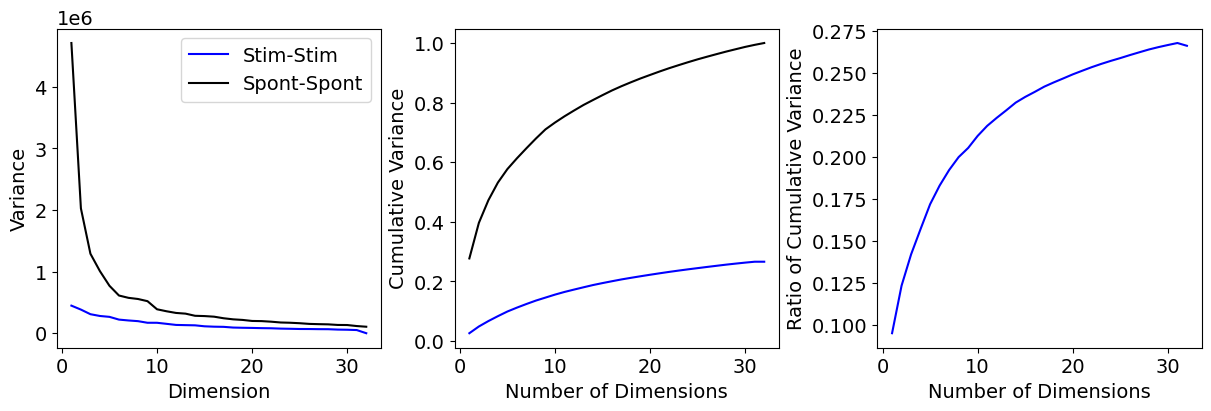

In [ ]:
xvals = lambda x: range(1, len(x) + 1)
norm = lambda x: x / np.sum(x)
total_spont = np.nansum(variance_spont)

offsets = 0.00
plt.close("all")
fig, ax = plt.subplots(1, 3, figsize=(12, 4), layout="constrained", width_ratios=[1, 1, 1])
ax[0].plot(xvals(variance_stim), variance_stim, label="Stim-Stim", color="Blue")
ax[0].plot(xvals(variance_spont), variance_spont, label="Spont-Spont", color="Black")
ax[0].legend()
ax[0].set_xlabel("Dimension")
ax[0].set_ylabel("Variance")

cumulative_stim = np.cumsum(variance_stim) / total_spont
cumulative_spont = np.cumsum(variance_spont) / total_spont
ax[1].plot(xvals(cumulative_stim), cumulative_stim, label="Stim-Stim", color="Blue")
ax[1].plot(xvals(cumulative_spont), cumulative_spont, label="Spont-Spont", color="Black")
ax[1].set_xlabel("Number of Dimensions")
ax[1].set_ylabel("Cumulative Variance")

ratio = cumulative_stim / cumulative_spont
ax[2].plot(xvals(cumulative_stim), ratio, label="Stim-Stim", color="Blue")
ax[2].set_xlabel("Number of Dimensions")
ax[2].set_ylabel("Ratio of Cumulative Variance")
plt.show()